# Ejercicio 5. Incorporación de 2024

El script de descarga se ejecutó con `ANIOS = (2024, 2026)`. Las consultas de este notebook están en `sql/03_incorporacion_anios.sql` y ninguna menciona un año concreto, todas descubren los años desde los archivos.

In [1]:
import sys
sys.path.append("../scripts")

import matplotlib.pyplot as plt
import pandas as pd
from consultas import cargar_consultas, conectar, ejecutar
from graficas import COLORES, NOMBRES, miles

con = conectar()
q = cargar_consultas("03_incorporacion_anios.sql")

## 5.5 Los archivos nuevos se incorporaron

**Objetivo.** Contar archivos y registros por tipo y año leyendo solo los metadatos.

In [2]:
ejecutar(con, q, "archivos_por_anio")

SELECT
    split_part(file_name, '/', 3) AS tipo_taxi,
    split_part(file_name, '/', 4) AS anio,
    count(*) AS archivos,
    min(regexp_extract(file_name, '(\d{4}-\d{2})\.parquet$', 1)) AS primer_mes,
    max(regexp_extract(file_name, '(\d{4}-\d{2})\.parquet$', 1)) AS ultimo_mes,
    sum(num_rows) AS registros
FROM parquet_file_metadata('data/raw/*/*/*.parquet')
GROUP BY ALL
ORDER BY tipo_taxi, anio;

[archivos_por_anio] 4 filas en 0.01 s


,tipo_taxi,anio,archivos,primer_mes,ultimo_mes,registros
0,green,2024,12,2024-01,2024-12,660218.0
1,green,2026,8,2026-01,2026-08,337114.0
2,yellow,2024,12,2024-01,2024-12,41169720.0
3,yellow,2026,8,2026-01,2026-08,29703355.0


**Resultado.** Se agregaron 24 archivos, de enero a diciembre de 2024 para cada tipo, con 41,169,720 viajes amarillos y 660,218 verdes. Los 16 archivos de 2026 siguen ahí. La salida de la descarga (`docs/descarga_2024.txt`) muestra 24 descargados y 16 omitidos por existir, y `--verificar` reporta 0 archivos con problemas (`docs/verificacion_2024_2026.txt`).

**Objetivo.** Confirmar que la vista `viajes` lee todos los registros de cada archivo nuevo.

In [3]:
ejecutar(con, q, "conteo_metadatos_vs_datos")

WITH metadatos AS (
    SELECT
        split_part(file_name, '/', 3) AS tipo_taxi,
        split_part(file_name, '/', 4)::INTEGER AS anio,
        sum(num_rows) AS registros_metadatos
    FROM parquet_file_metadata('data/raw/*/*/*.parquet')
    GROUP BY ALL
),
datos AS (
    SELECT tipo_taxi, anio_archivo AS anio, count(*) AS registros_vista
    FROM viajes
    GROUP BY ALL
)
SELECT m.*, d.registros_vista, m.registros_metadatos = d.registros_vista AS coincide
FROM metadatos m
JOIN datos d USING (tipo_taxi, anio)
ORDER BY tipo_taxi, anio;

[conteo_metadatos_vs_datos] 4 filas en 0.05 s


,tipo_taxi,anio,registros_metadatos,registros_vista,coincide
0,green,2024,660218.0,660218,True
1,green,2026,337114.0,337114,True
2,yellow,2024,41169720.0,41169720,True
3,yellow,2026,29703355.0,29703355,True


**Resultado.** Los cuatro conteos de la vista coinciden con los metadatos.

## 5.6 Consulta conjunta de 2024 y 2026

**Objetivo.** Comparar mes a mes los dos años en una sola consulta. `PIVOT` crea una columna por cada año presente.

-- PIVOT crea una columna por cada anio que exista, sin escribirlos en la consulta
PIVOT (
    SELECT tipo_taxi, mes_archivo AS mes, anio_archivo::VARCHAR AS anio
    FROM viajes_validos
)
ON anio
USING count(*)
GROUP BY tipo_taxi, mes
ORDER BY tipo_taxi, mes;



[consulta_conjunta_por_mes] 24 filas en 1.76 s


,tipo_taxi,mes,2024,2026,cambio_pct
0,green,1,52730,38246,-27.5
1,green,2,49900,35306,-29.2
2,green,3,53569,42011,-21.6
3,green,4,52348,41874,-20.0
4,green,5,56799,42529,-25.1
5,green,6,51094,41925,-17.9
6,green,7,47950,38869,-18.9
7,green,8,48019,38252,-20.3
12,yellow,1,2859142,3505447,22.6
13,yellow,2,2891308,3200797,10.7


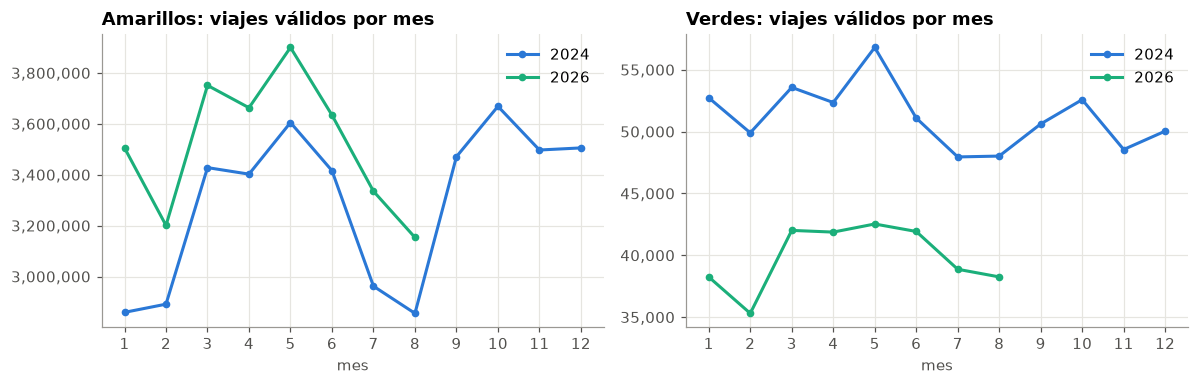

In [4]:
por_mes = ejecutar(con, q, "consulta_conjunta_por_mes")
comunes = por_mes[por_mes["2026"] > 0].copy()
comunes["cambio_pct"] = (100 * (comunes["2026"] - comunes["2024"]) / comunes["2024"]).round(1)

fig, ejes = plt.subplots(1, 2, figsize=(11, 3.6))
for eje, tipo in zip(ejes, ["yellow", "green"]):
    datos = por_mes[por_mes.tipo_taxi == tipo]
    for anio in ["2024", "2026"]:
        serie = datos[datos[anio] > 0]
        eje.plot(serie.mes, serie[anio], color=COLORES[int(anio)], marker="o", markersize=4, label=anio)
    eje.set_title(f"{NOMBRES[tipo]}: viajes válidos por mes")
    eje.set_xticks(range(1, 13))
    eje.set_xlabel("mes")
    eje.legend()
    miles(eje)
plt.tight_layout()
comunes

**Resultado.** La consulta conjunta funciona sin cambios. Entre los mismos meses, los amarillos crecieron en 2026 entre 6.4 % (junio) y 22.6 % (enero), y los verdes cayeron entre 17.9 % (junio) y 29.2 % (febrero).

## 5.7 Las consultas anteriores no necesitan cambios para correr

**Objetivo.** Revisar si el esquema cambia entre años, que es lo único que podría romper las consultas.

In [5]:
ejecutar(con, q, "columnas_por_anio")

-- Solo muestra las columnas que no estan en todos los archivos de su tipo de taxi
WITH esquema AS (
    SELECT
        split_part(file_name, '/', 3) AS tipo_taxi,
        split_part(file_name, '/', 4) AS anio,
        file_name,
        name AS columna
    FROM parquet_schema('data/raw/*/*/*.parquet')
    WHERE name NOT IN ('schema', 'duckdb_schema')
),
total AS (
    SELECT tipo_taxi, count(DISTINCT file_name) AS archivos FROM esquema GROUP BY tipo_taxi
)
SELECT
    e.tipo_taxi,
    e.columna,
    count(DISTINCT e.file_name) AS archivos_con_columna,
    any_value(t.archivos) AS archivos_del_tipo,
    string_agg(DISTINCT e.anio, ', ' ORDER BY e.anio) AS anios_con_columna
FROM esquema e
JOIN total t USING (tipo_taxi)
GROUP BY e.tipo_taxi, e.columna
HAVING count(DISTINCT e.file_name) < any_value(t.archivos)
ORDER BY e.tipo_taxi, e.columna;



[columnas_por_anio] 4 filas en 0.04 s


,tipo_taxi,columna,archivos_con_columna,archivos_del_tipo,anios_con_columna
0,green,cbd_congestion_fee,8,20,2026
1,green,request_source,3,20,2026
2,yellow,cbd_congestion_fee,8,20,2026
3,yellow,request_source,3,20,2026


In [6]:
ejecutar(con, q, "tipos_por_anio")

SELECT
    split_part(file_name, '/', 4) AS anio,
    name AS columna,
    string_agg(DISTINCT type, ', ') AS tipo_fisico
FROM parquet_schema('data/raw/yellow/*/*.parquet')
WHERE name IN ('passenger_count', 'RatecodeID', 'payment_type', 'VendorID', 'PULocationID')
GROUP BY ALL
ORDER BY columna, anio;

[tipos_por_anio] 10 filas en 0.01 s


,anio,columna,tipo_fisico
0,2024,PULocationID,INT32
1,2026,PULocationID,INT32
2,2024,RatecodeID,INT64
3,2026,RatecodeID,INT64
4,2024,VendorID,INT32
5,2026,VendorID,INT32
6,2024,passenger_count,INT64
7,2026,passenger_count,INT64
8,2024,payment_type,INT64
9,2026,payment_type,INT64


**Resultado.** Los tipos físicos son iguales en los dos años. Solo cambian dos columnas, `cbd_congestion_fee` y `request_source`, que no existen en 2024. Con `union_by_name = true` DuckDB las llena con nulos en los archivos de 2024, y las consultas que usan `cbd_congestion_fee` ya aplicaban `coalesce(..., 0)`. Tiene sentido que sea 0, porque el cargo por congestión de Manhattan empezó en enero de 2025.

**Lo que sí cambia es el significado.** Las consultas del Ejercicio 4 que solo agrupan por `tipo_taxi` ahora mezclan los dos años. Por ejemplo, los amarillos sin forma de pago bajan de 25.01 % a 15.85 % al sumar 2024. Corren igual, pero cuando la pregunta es por año hay que agregar `anio_archivo` al `GROUP BY`, como en la siguiente consulta.

In [7]:
ejecutar(con, q, "resumen_por_anio")

SELECT
    tipo_taxi,
    anio_archivo AS anio,
    count(*) AS viajes_validos,
    round(median(trip_distance), 2) AS distancia_mediana,
    round(median(total_amount), 2) AS total_mediano,
    round(avg(coalesce(cbd_congestion_fee, 0)), 2) AS cargo_cbd_promedio
FROM viajes_validos
GROUP BY tipo_taxi, anio_archivo
ORDER BY tipo_taxi, anio;



[resumen_por_anio] 4 filas en 3.35 s


,tipo_taxi,anio,viajes_validos,distancia_mediana,total_mediano,cargo_cbd_promedio
0,green,2024,614188,1.99,19.26,0.00
1,green,2026,319012,2.16,20.52,0.06
2,yellow,2024,39561014,1.80,21.20,0.00
3,yellow,2026,28143421,1.94,23.58,0.54


**Resultado.** El viaje típico se alargó y encareció. En amarillos la distancia mediana pasó de 1.80 a 1.94 millas y el total mediano de 21.20 a 23.58 dólares, con 0.54 dólares promedio de cargo CBD que en 2024 no existía.